In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
df = pd.read_csv("/content/Merged_Dataset_Training.csv", encoding="latin1")
new_df = pd.read_csv(
    "/content/Merged_Dataset_Testing.csv",   
    encoding="latin1"
)

In [ ]:
import pandas as pd
import numpy as np

# ---------- TRAIN DATA ----------
df = pd.read_csv("/content/Merged_Dataset_Training.csv", encoding="latin1")
df = df.replace("<LOD", 0)

df = df.dropna(how="all").reset_index(drop=True)

print("Clean df shape:", df.shape)
print("Empty rows in df:", (df.isna().all(axis=1)).sum())

# ---------- NEW / INFERENCE DATA ----------
new_df = pd.read_csv("/content/Merged_Dataset_Testing.csv", encoding="latin1")
new_df = new_df.replace("<LOD", 0)

new_df = new_df.dropna(how="all").reset_index(drop=True)

print("Clean new_df shape:", new_df.shape)
print("Empty rows in new_df:", (new_df.isna().all(axis=1)).sum())


Clean df shape: (206, 118)
Empty rows in df: 0
Clean new_df shape: (23, 118)
Empty rows in new_df: 0


In [ ]:

rows_df = set(map(tuple, df.values))
rows_new = set(map(tuple, new_df.values))

common_unique_rows = rows_df & rows_new
print("Number of UNIQUE identical rows:", len(common_unique_rows))


Number of UNIQUE identical rows: 0


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline

# Load CSV
df = pd.read_csv("/content/Merged_Dataset_Training.csv", encoding="latin1")

# Clean missing values (<LOD → 0, NaN → 0)
df = df.replace("<LOD", 0)
df = df.replace(np.nan, 0)

# Feature range: from L_mean to K_mean (inclusive)
col_start = df.columns.get_loc("L_mean")
col_end = df.columns.get_loc("K_mean") + 1
feature_cols = df.columns[col_start:col_end]

targets = [
    "pH",
    "EC (ÂµS)",
    "VS (%)",
    "ASH (%)",
    "Bulk Density Kg/m^3",
]

# Optimized KNN hyperparameter grid
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor())
])

knn_params = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 15, 20],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],              # Manhattan & Euclidean
    "knn__leaf_size": [20, 30, 40],
}

def run_knn_for_target(df, feature_cols, target):

    X = df[feature_cols].astype(float)
    y = df[target].astype(float)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    grid = GridSearchCV(
        estimator=knn_pipeline,
        param_grid=knn_params,
        scoring="neg_mean_squared_error",
        cv=5,
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    print("\n=============================================")
    print(f"   TARGET VARIABLE: {target}")
    print("=============================================\n")

    print("✔ Best Params:", grid.best_params_)
    print("✔ Best CV MSE:", -grid.best_score_)

    # Evaluate on test set (R²)
    best_model = grid.best_estimator_
    test_r2 = best_model.score(X_test, y_test)
    print("✔ Test R²:", test_r2)

    return best_model

models = {}

for target in targets:
    model = run_knn_for_target(df, feature_cols, target)
    models[target] = model


   TARGET VARIABLE: pH

✔ Best Params: {'knn__leaf_size': 20, 'knn__n_neighbors': 3, 'knn__p': 2, 'knn__weights': 'distance'}
✔ Best CV MSE: 0.06685517779313384
✔ Test R²: 0.8977849997929301

   TARGET VARIABLE: EC (ÂµS)

✔ Best Params: {'knn__leaf_size': 20, 'knn__n_neighbors': 3, 'knn__p': 2, 'knn__weights': 'uniform'}
✔ Best CV MSE: 1090639.9835986954
✔ Test R²: 0.869387247656457

   TARGET VARIABLE: VS (%)

✔ Best Params: {'knn__leaf_size': 20, 'knn__n_neighbors': 3, 'knn__p': 2, 'knn__weights': 'uniform'}
✔ Best CV MSE: 30.528992154882154
✔ Test R²: 0.9011251815849975

   TARGET VARIABLE: ASH (%)

✔ Best Params: {'knn__leaf_size': 20, 'knn__n_neighbors': 3, 'knn__p': 2, 'knn__weights': 'uniform'}
✔ Best CV MSE: 30.52848373316498
✔ Test R²: 0.9011275657310904

   TARGET VARIABLE: Bulk Density Kg/m^3

✔ Best Params: {'knn__leaf_size': 20, 'knn__n_neighbors': 3, 'knn__p': 2, 'knn__weights': 'uniform'}
✔ Best CV MSE: 1174.9579124579122
✔ Test R²: 0.7920924292213783


In [ ]:
from sklearn.metrics import r2_score

# LOAD NEW DATA (INFERENCE DATASET)

new_df = pd.read_csv(
    "/content/Merged_Dataset_Testing.csv",  
    encoding="latin1"
)

# Same cleaning as training
new_df = new_df.replace("<LOD", 0)
new_df = new_df.replace(np.nan, 0)

# EXTRACT SAME FEATURES & TARGETS

# Use same feature columns determined earlier
X_new = new_df[feature_cols].astype(float)

# RUN INFERENCE & DISPLAY R² PER TARGET

print("\n=============================================")
print("      INFERENCE RESULTS ON NEW DATASET")
print("=============================================\n")

inference_results = {}

for target in targets:

    y_true = new_df[target].astype(float)

    model = models[target]   # trained model from earlier loop

    # Predict on NEW dataset
    y_pred = model.predict(X_new)

    # Calculate R²
    r2 = r2_score(y_true, y_pred)
    inference_results[target] = r2

    print(f" TARGET: {target}")
    print(f"   R² Score on new dataset: {r2:.6f}")
    print("---------------------------------------------")

# SUMMARY TABLE

summary_df = pd.DataFrame.from_dict(
    inference_results, orient="index", columns=["Test_R2_New_Dataset"]
)

summary_df



      INFERENCE RESULTS ON NEW DATASET

 TARGET: pH
   R² Score on new dataset: 0.947732
---------------------------------------------
 TARGET: EC (ÂµS)
   R² Score on new dataset: 0.969705
---------------------------------------------
 TARGET: VS (%)
   R² Score on new dataset: 0.943039
---------------------------------------------
 TARGET: ASH (%)
   R² Score on new dataset: 0.943047
---------------------------------------------
 TARGET: Bulk Density Kg/m^3
   R² Score on new dataset: 0.870728
---------------------------------------------


,Test_R2_New_Dataset
pH,0.947732
EC (ÂµS),0.969705
VS (%),0.943039
ASH (%),0.943047
Bulk Density Kg/m^3,0.870728


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
results = []

for target in targets:
    y_true = new_df[target].astype(float)
    y_pred = models[target].predict(X_new)

    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    results.append([target, r2, mae, rmse])

metrics_new = pd.DataFrame(results, columns=["Target", "R2", "MAE", "RMSE"])
metrics_new


,Target,R2,MAE,RMSE
0,pH,0.947732,0.176649,0.213108
1,EC (ÂµS),0.969705,314.444928,489.995465
2,VS (%),0.943039,3.452029,4.802717
3,ASH (%),0.943047,3.451884,4.802385
4,Bulk Density Kg/m^3,0.870728,18.550725,26.232701


,Target,R2,MAE,RMSE,Samples
0,pH,0.947732,0.176649,0.213108,23
1,EC (ÂµS),0.969705,314.444928,489.995465,23
2,VS (%),0.943039,3.452029,4.802717,23
3,ASH (%),0.943047,3.451884,4.802385,23
4,Bulk Density Kg/m^3,0.870728,18.550725,26.232701,23


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Summary visualization saved to 'moe_summary_plots.png'


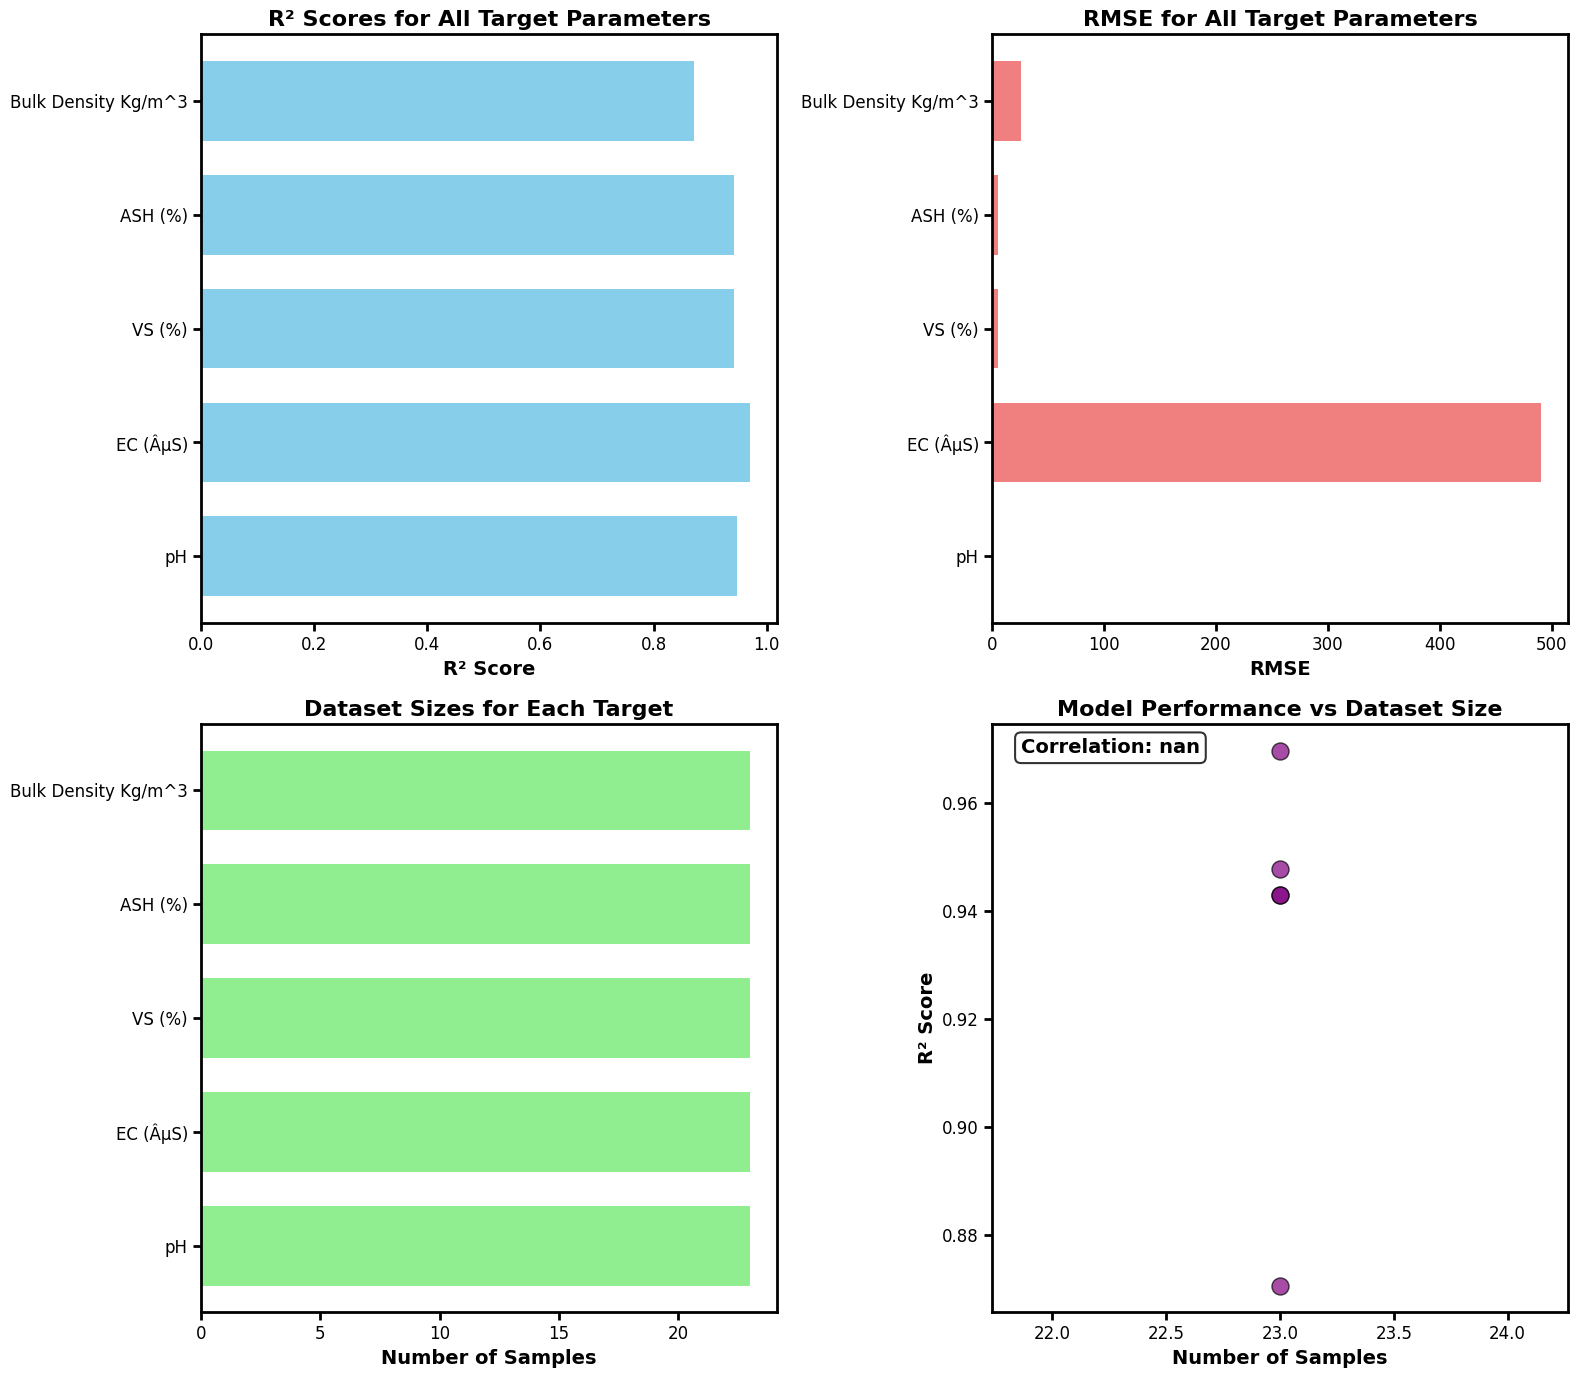

Results saved to 'moe_model_results.xlsx'


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# 1. Compute metrics on the unseen dataset

results = []

for target in targets:
    y_true = new_df[target].astype(float)
    y_pred = models[target].predict(X_new)

    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    n_samples = len(y_true)

    results.append([target, r2, mae, rmse, n_samples])

all_moe_results = pd.DataFrame(
    results,
    columns=["Target", "R2", "MAE", "RMSE", "Samples"]
)

display(all_moe_results)


# 2. Plotting summary graphs

# Setting global font parameters for all plots
plt.rcParams.update({
    'font.size': 14,         
    'axes.titlesize': 16,    
    'axes.labelsize': 14,    
    'xtick.labelsize': 12,   
    'ytick.labelsize': 12,   
    'legend.fontsize': 12   
})

# Creating comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Setting general plot parameters for all subplots
for ax in axes.flat:
    ax.grid(False)  # Remove grid
    # Setting all spines visible and customize them
    for spine in ['top', 'bottom', 'left', 'right']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(2)
        ax.spines[spine].set_color('black')
    # Customize tick parameters
    ax.tick_params(axis='both', which='major', width=2, length=6,
                   colors='black', labelsize=12)

# 1. R² scores
axes[0, 0].barh(all_moe_results['Target'], all_moe_results['R2'],
                color='skyblue', height=0.7)
axes[0, 0].set_xlabel('R² Score', fontweight='bold', fontsize=14)
axes[0, 0].set_title('R² Scores for All Target Parameters',
                     fontweight='bold', fontsize=16)
axes[0, 0].tick_params(axis='y', labelsize=12)

# 2. RMSE values
axes[0, 1].barh(all_moe_results['Target'], all_moe_results['RMSE'],
                color='lightcoral', height=0.7)
axes[0, 1].set_xlabel('RMSE', fontweight='bold', fontsize=14)
axes[0, 1].set_title('RMSE for All Target Parameters',
                     fontweight='bold', fontsize=16)
axes[0, 1].tick_params(axis='y', labelsize=12)

# 3. Sample sizes
axes[1, 0].barh(all_moe_results['Target'], all_moe_results['Samples'],
                color='lightgreen', height=0.7)
axes[1, 0].set_xlabel('Number of Samples', fontweight='bold', fontsize=14)
axes[1, 0].set_title('Dataset Sizes for Each Target',
                     fontweight='bold', fontsize=16)
axes[1, 0].tick_params(axis='y', labelsize=12)

# 4. Performance vs Sample Size
axes[1, 1].scatter(all_moe_results['Samples'], all_moe_results['R2'],
                   s=150, alpha=0.7, color='purple',
                   edgecolor='black', linewidth=1)
axes[1, 1].set_xlabel('Number of Samples', fontweight='bold', fontsize=14)
axes[1, 1].set_ylabel('R² Score', fontweight='bold', fontsize=14)
axes[1, 1].set_title('Model Performance vs Dataset Size',
                     fontweight='bold', fontsize=16)

# Add correlation coefficient
correlation = all_moe_results['Samples'].corr(all_moe_results['R2'])
axes[1, 1].text(
    0.05, 0.95, f'Correlation: {correlation:.3f}',
    transform=axes[1, 1].transAxes,
    bbox=dict(boxstyle="round", facecolor='white', alpha=0.8,
              edgecolor='black', linewidth=1.5),
    fontweight='bold', fontsize=14
)

plt.tight_layout()
plt.savefig('moe_summary_plots.png', dpi=300, bbox_inches='tight')
print("Summary visualization saved to 'moe_summary_plots.png'")
plt.show()

# 3. Saving metrics to Excel
all_moe_results.to_excel('moe_model_results.xlsx', index=False)
print("Results saved to 'moe_model_results.xlsx'")
